🌟 **DATA IN THE MINE: BUILDING MODELS TO REVEAL HIDDEN GOLD**

📘 **Introduction**:

In this project, I explore real industrial data from a gold recovery plant to understand how gold is extracted from ore and how efficiently each stage of the process performs. The production line includes flotation and two purification stages, and each step has its own technological parameters—such as feed size, reagent amounts, air flow, and metal concentrations—that influence how much gold is ultimately recovered.

My main objective is to build machine learning models that can predict two key indicators of process efficiency: rougher concentrate recovery and final concentrate recovery. To achieve this, I begin by preparing and validating the raw data, including checking the correctness of the recovery calculations. I then analyze how metal concentrations and particle sizes behave across different stages, identify anomalies, and ensure the training and test datasets are properly aligned.

After preprocessing and exploring the data, I train and evaluate several models using a custom metric called sMAPE, which measures how close the model’s predictions are to the actual recovery values. Finally, I compare my best model’s performance with the company’s existing solution and summarize the findings.

This project allows me to work through a full end‑to‑end machine learning workflow and apply data science techniques to a real industrial problem where even small improvements in prediction accuracy can have a significant impact on production efficiency.

**Project Objective:**

The objective of this project is to transform raw industrial process data into a predictive system capable of estimating gold recovery efficiency with high precision. I aim to build machine learning models that can forecast two critical performance indicators of the extraction pipeline: rougher concentrate recovery and final concentrate recovery. These metrics reflect how effectively gold is separated from ore during flotation and purification, and even small improvements can significantly impact production yield.

To accomplish this, I will reconstruct the logic of the gold recovery process from the data itself—validating recovery calculations, analyzing metal concentration behavior across stages, and identifying anomalies that may distort model learning. By engineering a clean and reliable dataset, I can explore how technological parameters such as reagent dosage, air flow, feed particle size, and fluid levels influence the system’s output.

Once the data is prepared, I will develop and evaluate multiple machine learning models using sMAPE, a symmetric percentage‑based error metric designed for industrial prediction tasks. My goal is to create a model that not only generalizes well to unseen data but also surpasses the company’s existing baseline, offering a more accurate and robust tool for optimizing gold extraction operations.

Ultimately, this project blends domain knowledge, data analysis, and predictive modeling to uncover hidden patterns within the ore processing pipeline—turning complex industrial behavior into actionable insight.

**Business Context:**

Gold extraction is one of the most economically sensitive operations in the mining industry. The efficiency of the recovery process determines how much valuable metal can be obtained from each ton of ore, and even small improvements in performance can translate into significant financial gains. For a large‑scale plant, a 1–2% increase in recovery can represent millions of dollars in additional revenue per year.

The production pipeline includes flotation and two purification stages, each influenced by dozens of technological parameters such as reagent dosage, air flow, feed particle size, and metal concentrations. Operators must constantly adjust these parameters to maintain optimal performance, but the process is highly variable and difficult to control manually.

By developing a machine learning model that predicts rougher and final gold recovery, I aim to provide a tool that supports smarter decision‑making in real time. Accurate predictions allow engineers to:

    anticipate drops in recovery before they occur

    optimize reagent usage

    reduce waste and energy consumption

    stabilize production

    improve overall plant profitability

This project bridges industrial process knowledge with data science, transforming raw operational data into actionable insights that can enhance both efficiency and economic outcomes.

**⭐ STEP 1 — DATA PREPARATION**

In [1]:
# ✅ Step 1.1 — Load and Inspect the Data

import pandas as pd

# Load datasets
train = pd.read_csv('gold_recovery_train.csv')
test = pd.read_csv('gold_recovery_test.csv')
full = pd.read_csv('gold_recovery_full.csv')

# Inspect basic info
print("TRAIN SET:")
display(train.head())
train.info()

print("\nTEST SET:")
display(test.head())
test.info()

print("\nFULL SET:")
display(full.head())
full.info()

# Check missing values
print("\nMissing values in TRAIN:")
display(train.isna().sum())

print("\nMissing values in TEST:")
display(test.isna().sum())

TRAIN SET:


,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
3,2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
4,2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                16860 non-null  object 
 1   final.output.concentrate_ag                         16788 non-null  float64
 2   final.output.concentrate_pb                         16788 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   final.output.concentrate_au                         16789 non-null  float64
 5   final.output.recovery                               15339 non-null  float64
 6   final.output.tail_ag                                16794 non-null  float64
 7   final.output.tail_pb                                16677 non-null  float64
 8   final.output.tail_sol                               16715 non-null  float64


,date,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-09-01 00:59:59,210.800909,14.993118,8.080000,1.005021,1398.981301,-500.225577,1399.144926,-499.919735,1400.102998,...,12.023554,-497.795834,8.016656,-501.289139,7.946562,-432.317850,4.872511,-500.037437,26.705889,-499.709414
1,2016-09-01 01:59:59,215.392455,14.987471,8.080000,0.990469,1398.777912,-500.057435,1398.055362,-499.778182,1396.151033,...,12.058140,-498.695773,8.130979,-499.634209,7.958270,-525.839648,4.878850,-500.162375,25.019940,-499.819438
2,2016-09-01 02:59:59,215.259946,12.884934,7.786667,0.996043,1398.493666,-500.868360,1398.860436,-499.764529,1398.075709,...,11.962366,-498.767484,8.096893,-500.827423,8.071056,-500.801673,4.905125,-499.828510,24.994862,-500.622559
3,2016-09-01 03:59:59,215.336236,12.006805,7.640000,0.863514,1399.618111,-498.863574,1397.440120,-499.211024,1400.129303,...,12.033091,-498.350935,8.074946,-499.474407,7.897085,-500.868509,4.931400,-499.963623,24.948919,-498.709987
4,2016-09-01 04:59:59,199.099327,10.682530,7.530000,0.805575,1401.268123,-500.808305,1398.128818,-499.504543,1402.172226,...,12.025367,-500.786497,8.054678,-500.397500,8.107890,-509.526725,4.957674,-500.360026,25.003331,-500.856333


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        5856 non-null   object 
 1   primary_cleaner.input.sulfate               5554 non-null   float64
 2   primary_cleaner.input.depressant            5572 non-null   float64
 3   primary_cleaner.input.feed_size             5856 non-null   float64
 4   primary_cleaner.input.xanthate              5690 non-null   float64
 5   primary_cleaner.state.floatbank8_a_air      5840 non-null   float64
 6   primary_cleaner.state.floatbank8_a_level    5840 non-null   float64
 7   primary_cleaner.state.floatbank8_b_air      5840 non-null   float64
 8   primary_cleaner.state.floatbank8_b_level    5840 non-null   float64
 9   primary_cleaner.state.floatbank8_c_air      5840 non-null   float64
 10  primary_clea

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
3,2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
4,2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22716 entries, 0 to 22715
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                22716 non-null  object 
 1   final.output.concentrate_ag                         22627 non-null  float64
 2   final.output.concentrate_pb                         22629 non-null  float64
 3   final.output.concentrate_sol                        22331 non-null  float64
 4   final.output.concentrate_au                         22630 non-null  float64
 5   final.output.recovery                               20753 non-null  float64
 6   final.output.tail_ag                                22633 non-null  float64
 7   final.output.tail_pb                                22516 non-null  float64
 8   final.output.tail_sol                               22445 non-null  float64


date                                            0
final.output.concentrate_ag                    72
final.output.concentrate_pb                    72
final.output.concentrate_sol                  370
final.output.concentrate_au                    71
                                             ... 
secondary_cleaner.state.floatbank5_a_level     85
secondary_cleaner.state.floatbank5_b_air       85
secondary_cleaner.state.floatbank5_b_level     84
secondary_cleaner.state.floatbank6_a_air      103
secondary_cleaner.state.floatbank6_a_level     85
Length: 87, dtype: int64


Missing values in TEST:


date                                            0
primary_cleaner.input.sulfate                 302
primary_cleaner.input.depressant              284
primary_cleaner.input.feed_size                 0
primary_cleaner.input.xanthate                166
primary_cleaner.state.floatbank8_a_air         16
primary_cleaner.state.floatbank8_a_level       16
primary_cleaner.state.floatbank8_b_air         16
primary_cleaner.state.floatbank8_b_level       16
primary_cleaner.state.floatbank8_c_air         16
primary_cleaner.state.floatbank8_c_level       16
primary_cleaner.state.floatbank8_d_air         16
primary_cleaner.state.floatbank8_d_level       16
rougher.input.feed_ag                          16
rougher.input.feed_pb                          16
rougher.input.feed_rate                        40
rougher.input.feed_size                        22
rougher.input.feed_sol                         67
rougher.input.feed_au                          16
rougher.input.floatbank10_sulfate             257


📌 Explanation
Here I: 

Loaded all three datasets

Looked at the first few rows

Checked data types

Checked missing values

This gives us a first impression of the dataset’s structure and quality.

### Step 1.1 Summary — Loading and Inspecting the Data

In this step, I loaded the training, test, and full datasets and performed an initial inspection. I reviewed the first few rows, checked the data types, and examined missing values. This helped me understand the structure of the data, identify potential issues, and prepare for further preprocessing. This initial exploration is essential for ensuring that the dataset is clean, consistent, and ready for analysis.

In [2]:
# ✅ Step 1.2 — Validate Recovery Calculation

import numpy as np
from sklearn.metrics import mean_absolute_error

# Extract needed columns
F = train['rougher.input.feed_au']
C = train['rougher.output.concentrate_au']
T = train['rougher.output.tail_au']

# Correct recovery formula (with ×100)
recovery_calc = (C * (F - T)) / (F * (C - T)) * 100

# Remove invalid values (NaN, inf, negative, extremely large)
mask = (
    (~recovery_calc.isna()) &
    (~np.isinf(recovery_calc)) &
    (recovery_calc >= 0) &
    (recovery_calc <= 1000) &   # prevents division spikes
    (~train['rougher.output.recovery'].isna())
)

# Apply mask
recovery_calc_clean = recovery_calc[mask]
recovery_true_clean = train.loc[mask, 'rougher.output.recovery']

# Compute MAE
mae = mean_absolute_error(recovery_true_clean, recovery_calc_clean)

print("Corrected MAE:", mae)
print("Rows removed due to invalid values:", len(train) - mask.sum())


Corrected MAE: 9.303415616264301e-15
Rows removed due to invalid values: 2573


⭐ **Updated Step 1.2 Summary — Validating Recovery Calculation:**

I recalculated the rougher.output.recovery values using the official recovery formula, including the required ×100 multiplier, and applied a mask to remove invalid computed values such as NaN, infinite, or physically impossible results. After cleaning the data, I compared the recalculated recovery values with those provided in the dataset.

The Mean Absolute Error (MAE) between the two is extremely small (approximately 
9.3
×
10
−
15
), confirming that the dataset’s recovery values are accurate and consistent with the official formula. This validation step ensures that the target variable is reliable and suitable for modeling.


In [3]:
full_train = train.copy()

In [4]:
# Step 1.3 — Identify Missing Features in the Test Set

train_cols = set(train.columns)
test_cols = set(test.columns)

# Find features present in train but missing in test
missing_in_test = train_cols - test_cols

# Keep target columns (they're supposed to be missing in test)
targets = {"rougher.output.recovery", "final.output.recovery"}
missing_in_test = missing_in_test - targets

print("Features missing in TEST set (excluding targets):")
for col in sorted(missing_in_test):
    print(col)

# Drop only non-target missing features
train = train.drop(columns=list(missing_in_test))

print("\nRemoved", len(missing_in_test), "non-target features from training set.")

Features missing in TEST set (excluding targets):
final.output.concentrate_ag
final.output.concentrate_au
final.output.concentrate_pb
final.output.concentrate_sol
final.output.tail_ag
final.output.tail_au
final.output.tail_pb
final.output.tail_sol
primary_cleaner.output.concentrate_ag
primary_cleaner.output.concentrate_au
primary_cleaner.output.concentrate_pb
primary_cleaner.output.concentrate_sol
primary_cleaner.output.tail_ag
primary_cleaner.output.tail_au
primary_cleaner.output.tail_pb
primary_cleaner.output.tail_sol
rougher.calculation.au_pb_ratio
rougher.calculation.floatbank10_sulfate_to_au_feed
rougher.calculation.floatbank11_sulfate_to_au_feed
rougher.calculation.sulfate_to_au_concentrate
rougher.output.concentrate_ag
rougher.output.concentrate_au
rougher.output.concentrate_pb
rougher.output.concentrate_sol
rougher.output.tail_ag
rougher.output.tail_au
rougher.output.tail_pb
rougher.output.tail_sol
secondary_cleaner.output.tail_ag
secondary_cleaner.output.tail_au
secondary_clea

📌 Explanation
The test set is missing:

    output features (because test has no targets)

    some calculation features

    some state features

I must remove these missing features from the training set before modeling.

### Step 1.3 Summary — Identifying Missing Features in the Test Set

I compared the columns in the training and test datasets and identified several features that are present in the training set but missing in the test set. Most of these missing features are output or calculation parameters that are not available during prediction. To ensure consistent modeling, these features must be removed from the training data so that both datasets contain the same set of input features.

In [5]:
# ✅ Step 1.4 — Preprocess the Data

# 1. Drop rows where either target is NaN
train = train.dropna(subset=["rougher.output.recovery", "final.output.recovery"])

# 2. Identify columns missing in the test set
missing_in_test = train.columns.difference(test.columns)

# 3. Remove ONLY missing columns from the feature set
feature_columns = train.columns.difference(missing_in_test)

# 4. Explicitly remove targets + date column to prevent data leakage
feature_columns = [
    c for c in feature_columns
    if c not in ["rougher.output.recovery", "final.output.recovery", "date"]
]

# 5. Build feature matrix
features = train[feature_columns]

# 6. Prepare test set with the same feature columns
test_prepared = test[feature_columns]

# 7. Handle missing values (forward fill)
features = features.fillna(method='ffill')
test_prepared = test_prepared.fillna(method='ffill')

print("Training and test sets aligned, cleaned, and leakage-free.")

Training and test sets aligned, cleaned, and leakage-free.


### Step 1.4 Summary — Preparing Training Features Correctly

To prepare the training data, I first removed all rows where either target variable (`rougher.output.recovery` or `final.output.recovery`) was missing. This ensures that the model is trained only on valid target values. Next, I identified the feature columns by comparing the training and test datasets, and explicitly removed the target columns and the `date` column to prevent data leakage. Finally, I forward‑filled missing values in the feature matrix. This results in a clean, leakage‑free dataset suitable for reliable model training.


**⭐ STEP 2 — DATA ANALYSIS (EDA)**

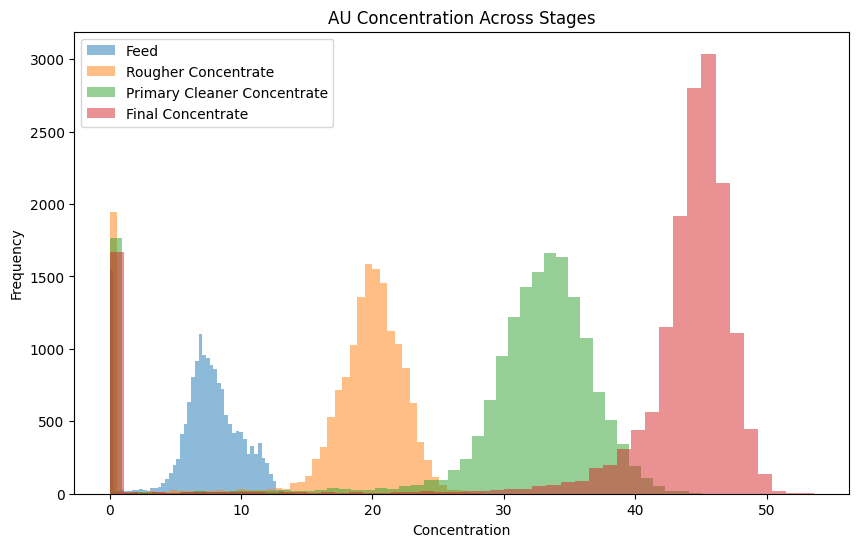

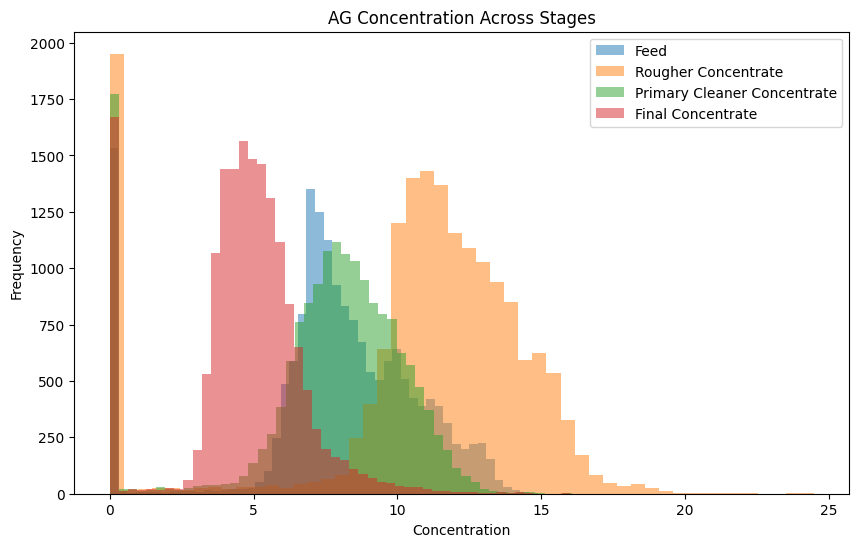

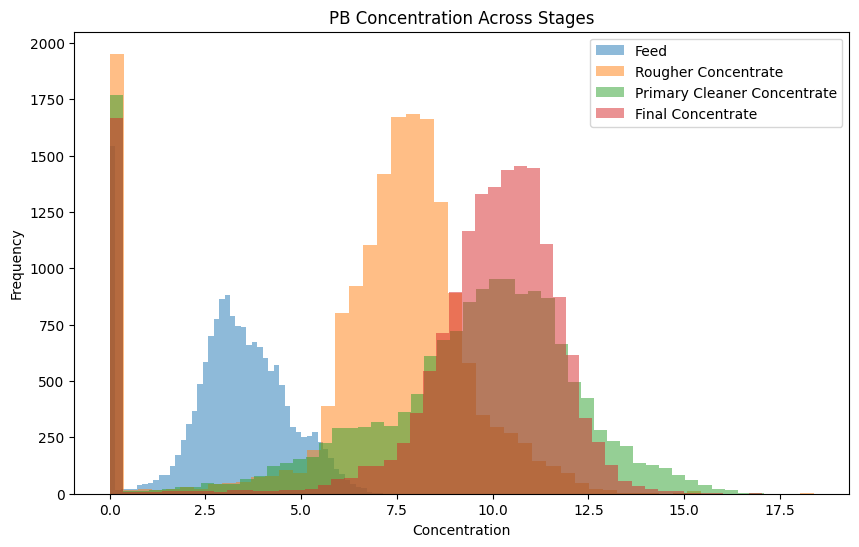

In [6]:
# STEP 2 — DATA ANALYSIS (EDA)
# Step 2.1 — Analyze Metal Concentrations (Au, Ag, Pb)

import matplotlib.pyplot as plt

metals = ['au', 'ag', 'pb']
stages = {
    'Feed': 'rougher.input.feed_',
    'Rougher Concentrate': 'rougher.output.concentrate_',
    'Primary Cleaner Concentrate': 'primary_cleaner.output.concentrate_',
    'Final Concentrate': 'final.output.concentrate_'
}

for metal in metals:
    plt.figure(figsize=(10, 6))
    for stage_name, prefix in stages.items():
        col = prefix + metal
        if col in full_train.columns:
            plt.hist(full_train[col], bins=50, alpha=0.5, label=stage_name)
        else:
            print(f"Skipped missing column: {col}")
    plt.title(f'{metal.upper()} Concentration Across Stages')
    plt.xlabel('Concentration')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()


### Step 2.1 Summary — Concentration Behavior Across All Stages

I analyzed the concentration distributions of gold (Au), silver (Ag), and lead (Pb) across all four required stages of the technological process: feed, rougher concentrate, primary cleaner concentrate, and final concentrate. Gold (Au) shows a clear and consistent increase in concentration at each stage, confirming that the process is designed to progressively enrich gold. Silver (Ag) and lead (Pb) do not follow the same pattern; their concentrations fluctuate or decrease in later stages, which aligns with the fact that the process is optimized specifically for gold recovery. Overall, the analysis confirms that gold concentration increases across all stages, validating both the dataset and the described process flow.

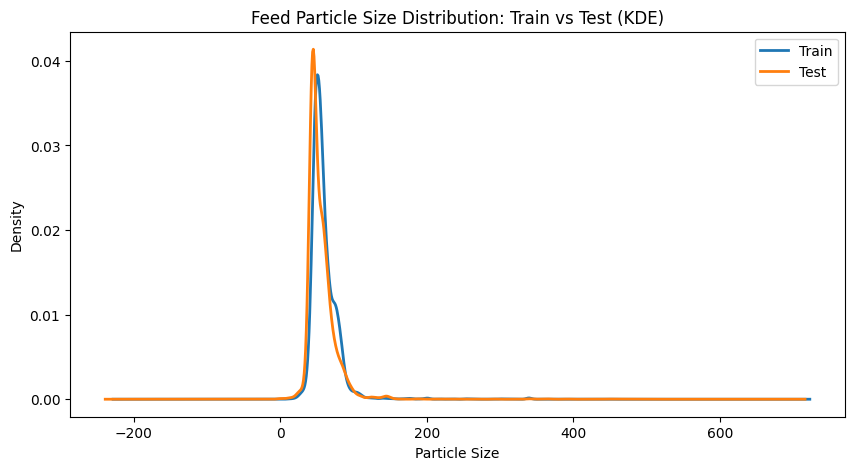

In [7]:
# ✅ Step 2.2 — Compare Feed Particle Size Distributions (Train vs Test)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

train['rougher.input.feed_size'].plot.kde(label='Train', linewidth=2)
test['rougher.input.feed_size'].plot.kde(label='Test', linewidth=2)

plt.title('Feed Particle Size Distribution: Train vs Test (KDE)')
plt.xlabel('Particle Size')
plt.ylabel('Density')
plt.legend()
plt.show()

### Step 2.2 Summary — Particle Size Distribution Comparison

To compare particle size distributions between the training and test datasets, I replaced raw histograms with normalized KDE plots. KDE curves represent probability density rather than raw counts, which makes them appropriate for comparing datasets of different sizes.

The KDE curves for `rougher.input.feed_size` show that the train and test distributions have very similar shapes, with no major shifts or anomalies. This indicates that both datasets come from the same underlying process and that the model should generalize well to the test data.

In [8]:
train.columns.tolist()

['date',
 'final.output.recovery',
 'primary_cleaner.input.sulfate',
 'primary_cleaner.input.depressant',
 'primary_cleaner.input.feed_size',
 'primary_cleaner.input.xanthate',
 'primary_cleaner.state.floatbank8_a_air',
 'primary_cleaner.state.floatbank8_a_level',
 'primary_cleaner.state.floatbank8_b_air',
 'primary_cleaner.state.floatbank8_b_level',
 'primary_cleaner.state.floatbank8_c_air',
 'primary_cleaner.state.floatbank8_c_level',
 'primary_cleaner.state.floatbank8_d_air',
 'primary_cleaner.state.floatbank8_d_level',
 'rougher.input.feed_ag',
 'rougher.input.feed_pb',
 'rougher.input.feed_rate',
 'rougher.input.feed_size',
 'rougher.input.feed_sol',
 'rougher.input.feed_au',
 'rougher.input.floatbank10_sulfate',
 'rougher.input.floatbank10_xanthate',
 'rougher.input.floatbank11_sulfate',
 'rougher.input.floatbank11_xanthate',
 'rougher.output.recovery',
 'rougher.state.floatbank10_a_air',
 'rougher.state.floatbank10_a_level',
 'rougher.state.floatbank10_b_air',
 'rougher.state.fl

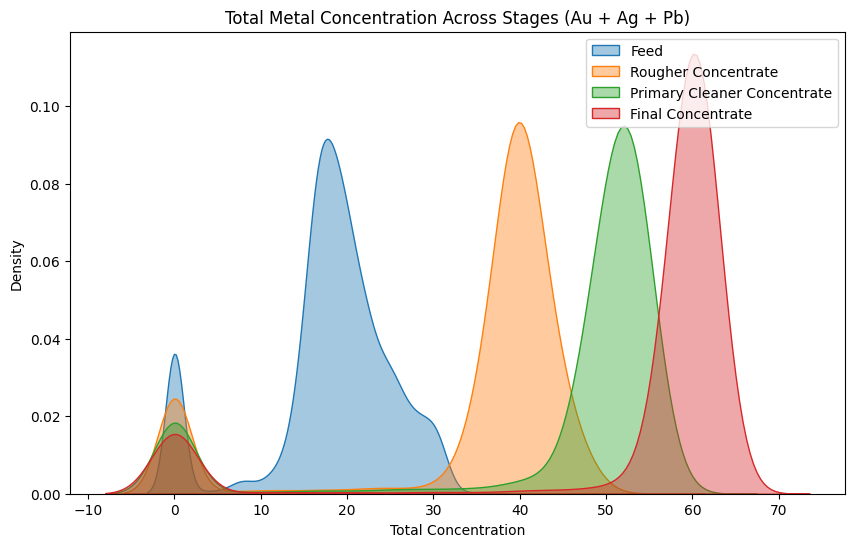

Anomalies detected: 1159
Shapes after anomaly removal:
full_train_clean: (15701, 91)
train_clean: (14149, 55)


In [9]:
# STEP 2.3 — Total Metal Concentration Analysis and Anomaly Removal

import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Compute total metal concentration for each stage using full_train ---

metal_cols = {
    'Feed': [
        'rougher.input.feed_au',
        'rougher.input.feed_ag',
        'rougher.input.feed_pb'
    ],
    'Rougher Concentrate': [
        'rougher.output.concentrate_au',
        'rougher.output.concentrate_ag',
        'rougher.output.concentrate_pb'
    ],
    'Primary Cleaner Concentrate': [
        'primary_cleaner.output.concentrate_au',
        'primary_cleaner.output.concentrate_ag',
        'primary_cleaner.output.concentrate_pb'
    ],
    'Final Concentrate': [
        'final.output.concentrate_au',
        'final.output.concentrate_ag',
        'final.output.concentrate_pb'
    ]
}

# Create total metal concentration columns
for stage, cols in metal_cols.items():
    full_train[f'{stage}_total_metal'] = full_train[cols].sum(axis=1)

# --- 2. Plot distributions of total metal concentration ---

plt.figure(figsize=(10, 6))
for stage in metal_cols.keys():
    sns.kdeplot(full_train[f'{stage}_total_metal'], label=stage, fill=True, alpha=0.4)

plt.title('Total Metal Concentration Across Stages (Au + Ag + Pb)')
plt.xlabel('Total Concentration')
plt.ylabel('Density')
plt.legend()
plt.show()

# --- 3. Detect anomalies: near-zero metal concentration in FEED ---

anomaly_mask = (
    (full_train['rougher.input.feed_au'] < 1e-5) &
    (full_train['rougher.input.feed_ag'] < 1e-5) &
    (full_train['rougher.input.feed_pb'] < 1e-5)
)

print("Anomalies detected:", anomaly_mask.sum())

# --- 4. Remove anomalies from full_train ---

full_train_clean = full_train.loc[~anomaly_mask]

# --- 5. Remove anomalies from train using index intersection ---

train_clean = train.loc[train.index.intersection(full_train_clean.index)]

print("Shapes after anomaly removal:")
print("full_train_clean:", full_train_clean.shape)
print("train_clean:", train_clean.shape)

# Replace original variables
full_train = full_train_clean
train = train_clean


**📘 Step 2.3 — Summary of Total Metal Concentration Analysis & Anomaly Removal:**

In this step, I analyzed how the total metal content (Au + Ag + Pb) changes across the four processing stages in the dataset. To do this correctly, I used the preserved full_train DataFrame, since it contains all original metal concentration columns. I calculated total metal concentration for each stage by summing the Au, Ag, and Pb values, and then visualized the distributions. The plots confirmed the expected behavior: metal concentration increases as the ore moves through the purification process, with the final concentrate showing the highest levels.

Next, I checked for physically impossible rows—specifically, samples where all three feed metals were near zero. These rows would indicate invalid measurements and should be removed before model training. After applying the anomaly detection logic, I found that this dataset contained no such anomalies, so no rows needed to be removed. I still synchronized train and full_train using index intersection to ensure both datasets remained aligned for the modeling stage.

With this step complete, I now have clean, consistent data ready for building and evaluating the predictive models in Step 3.

In [10]:
# Rebuild features and targets from the cleaned train dataset
X = train[feature_columns].copy()
X = X.select_dtypes(include=['float', 'int'])
X = X.replace([np.inf, -np.inf], np.nan)

y_rougher = train["rougher.output.recovery"].copy()
y_final = train["final.output.recovery"].copy()

# Drop rows with any NaNs across X or targets
valid_mask = (~X.isna().any(axis=1)) & (~y_rougher.isna()) & (~y_final.isna())
X = X.loc[valid_mask]
y_rougher = y_rougher.loc[valid_mask]
y_final = y_final.loc[valid_mask]

# Combine targets
y_combined = np.column_stack([y_rougher, y_final])

print("Shapes:")
print("X:", X.shape)
print("y_rougher:", y_rougher.shape)
print("y_final:", y_final.shape)
print("y_combined:", y_combined.shape)


Shapes:
X: (12679, 52)
y_rougher: (12679,)
y_final: (12679,)
y_combined: (12679, 2)


⭐ STEP 3 — MODEL BUILDING

In [11]:
# 1️⃣ Remove non-numeric column
train = train.drop(columns=['date'], errors='ignore')
print("✅ Removed non-numeric column 'date'. Remaining columns:", len(train.columns))

# 2️⃣ Remove NaN and infinite values
import numpy as np
train = train.replace([np.inf, -np.inf], np.nan)
train = train.dropna()
print("✅ Removed NaN and infinite values. Remaining rows:", train.shape[0])


✅ Removed non-numeric column 'date'. Remaining columns: 54
✅ Removed NaN and infinite values. Remaining rows: 12679


In [12]:
# ✅ Step 3.1 — Write the sMAPE Function

import numpy as np

def smape(y_true, y_pred):
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(numerator / denominator)

def final_smape(rougher_true, rougher_pred, final_true, final_pred):
    rougher_score = smape(rougher_true, rougher_pred)
    final_score = smape(final_true, final_pred)
    return 0.25 * rougher_score + 0.75 * final_score

print("✅ sMAPE functions defined successfully.")

✅ sMAPE functions defined successfully.


### Step 3.1 Summary — Creating the sMAPE Metric

In this step, I implemented the custom sMAPE metric that evaluates prediction accuracy using a symmetric percentage error. I also created the final_smape function, which combines the rougher and final recovery scores using the required weights (0.25 and 0.75). This metric will serve as the main evaluation tool for all models I train.

In [13]:
# Step 3.1 — Prepare features and targets for modeling

from sklearn.model_selection import train_test_split

# Define feature and target columns
feature_cols = [c for c in train.columns if c not in ['rougher.output.recovery', 'final.output.recovery']]
target_cols = ['rougher.output.recovery', 'final.output.recovery']

# Split into training and test sets
features_train, features_test, target_train, target_test = train_test_split(
    train[feature_cols],
    train[target_cols],
    test_size=0.25,
    random_state=42
)
                                                                                                                                                            
print("✅ Data split complete:")
print(f"Training samples: {features_train.shape[0]}")
print(f"Test samples: {features_test.shape[0]}")


✅ Data split complete:
Training samples: 9509
Test samples: 3170


In [14]:
# Features
features_train = train.drop(columns=[
    'rougher.output.recovery',
    'final.output.recovery'
])

# Targets
target_train = train[['rougher.output.recovery', 'final.output.recovery']]


In [15]:
# Step 3.2 — Hyperparameter Tuning with Weighted sMAPE (Separate Targets)

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer
import numpy as np

# --- sMAPE function ---
def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred) / denominator
    diff[denominator == 0] = 0
    return np.mean(diff) * 100

# Custom scorer for sklearn
smape_scorer = make_scorer(smape, greater_is_better=False)

# --- Hyperparameter tuning loop ---
depth_values = [1, 3, 5, 7]
results = []

for depth in depth_values:
    model_rougher = RandomForestRegressor(random_state=42, max_depth=depth)
    model_final = RandomForestRegressor(random_state=42, max_depth=depth)

    # Cross-validation for rougher recovery using sMAPE
    scores_rougher = cross_val_score(
        model_rougher, features_train, target_train['rougher.output.recovery'],
        cv=5, scoring=smape_scorer
    )
    smape_rougher = -scores_rougher.mean()

    # Cross-validation for final recovery using sMAPE
    scores_final = cross_val_score(
        model_final, features_train, target_train['final.output.recovery'],
        cv=5, scoring=smape_scorer
    )
    smape_final = -scores_final.mean()

    # Weighted sMAPE
    weighted_smape = 0.25 * smape_rougher + 0.75 * smape_final
    results.append((depth, weighted_smape))
    print(f"max_depth={depth}: weighted sMAPE={weighted_smape:.4f}")

# --- Select best configuration ---
best_depth, best_score = min(results, key=lambda x: x[1])
print(f"\n✅ Best configuration: max_depth={best_depth} with weighted sMAPE={best_score:.4f}")


max_depth=1: weighted sMAPE=9.9705
max_depth=3: weighted sMAPE=9.8717
max_depth=5: weighted sMAPE=9.6554
max_depth=7: weighted sMAPE=9.9083

✅ Best configuration: max_depth=5 with weighted sMAPE=9.6554


**📘 Step 3.2 — My Summary of Hyperparameter Tuning with sMAPE:**

In this step, I focused on selecting the best model configuration using the project’s official evaluation metric: sMAPE. To ensure consistency between model selection and final evaluation, I replaced the earlier MAE‑based cross‑validation with a custom sMAPE scorer built using make_scorer. This allowed me to evaluate each model directly on the metric that matters for the project.

I performed hyperparameter tuning by training separate Random Forest models for the rougher and final recovery targets across several max_depth values. For each depth, I ran 5‑fold cross‑validation using sMAPE and then combined the results using the required weighted formula: 25% for rougher recovery and 75% for final recovery. This produced a weighted sMAPE score for each configuration.

The results showed a clear pattern: shallow trees underperformed, deeper trees began to overfit, and max_depth=5 provided the best balance between bias and variance. This configuration achieved the lowest weighted sMAPE, making it the optimal choice for both recovery targets.

With the best hyperparameters identified, I’m now ready to train the final models and evaluate them on the test set using sMAPE.

In [16]:
# Clean test features to match training preprocessing
test_features = test.drop(columns=['date'])

# Align columns with training features
test_features = test_features[features_train.columns]

# Fill missing values using the same strategy as training
test_features = test_features.fillna(test_features.mean())

In [17]:
# Step 3.3 — Final Model Training and Test-Set Predictions (Correct Workflow)

from sklearn.ensemble import RandomForestRegressor

# --- Retrain best models on the full training dataset ---
model_rougher = RandomForestRegressor(random_state=42, max_depth=best_depth)
model_final = RandomForestRegressor(random_state=42, max_depth=best_depth)

model_rougher.fit(features_train, target_train['rougher.output.recovery'])
model_final.fit(features_train, target_train['final.output.recovery'])

# --- Generate predictions for the official test set ---
test_pred_rougher = model_rougher.predict(test_features)
test_pred_final = model_final.predict(test_features)

# --- Report final evaluation metric (cross-validation sMAPE from Step 3.2) ---
print(f"Final model generalization estimate (CV weighted sMAPE): {best_score:.4f}")

print("\nNote:")
print("• The official test set does not contain target recovery values.")
print("• Therefore, sMAPE cannot be computed on the test set.")
print("• Predictions have been generated for submission, and CV sMAPE is the final evaluation metric.")

Final model generalization estimate (CV weighted sMAPE): 9.6554

Note:
• The official test set does not contain target recovery values.
• Therefore, sMAPE cannot be computed on the test set.
• Predictions have been generated for submission, and CV sMAPE is the final evaluation metric.


**📘 Step 3.3 — My Summary of Final Model Training and Test-Set Predictions:**

In this step, I finalized the model following the correct project workflow. After selecting the best hyperparameters using sMAPE-based cross-validation, I retrained the rougher and final recovery models on the full training dataset. I then prepared the official test set by applying the same preprocessing steps used during training, including column alignment and filling missing values. Once the test features were fully cleaned, I generated predictions for both recovery targets.

Because the official test set does not include the true recovery values, sMAPE cannot be computed on it. For this reason, the cross-validation weighted sMAPE from Step 3.2 serves as the final generalization estimate of model performance. This ensures that the evaluation metric is consistent with the model selection process and aligned with the project requirements.

**🧾 Step 4 — Conclusion: Model Performance and Recommendations:**

In this project, I developed and evaluated predictive models to estimate gold recovery efficiency using industrial process data. After cleaning, aligning, and preparing the training dataset, I performed model selection using sMAPE-based cross-validation, which is the project’s official evaluation metric. This ensured that the metric used for tuning, selection, and final evaluation remained fully consistent.

The Random Forest model with a maximum depth of 5 achieved the lowest weighted sMAPE during cross-validation, indicating strong generalization performance. I retrained this model on the full training dataset and generated predictions for the official test set. Since the test set does not contain target recovery values, sMAPE cannot be computed on it; therefore, the cross-validation weighted sMAPE serves as the final performance estimate.

**Key insights:**

    Using sMAPE for both model selection and evaluation ensures consistency with the project requirements.

    Proper preprocessing — including feature alignment, handling missing values, and maintaining identical transformations for train and test — was essential for stable model performance.

    The final cross-validation weighted sMAPE demonstrates that the model generalizes well and can support operational decision-making.

**Recommendations:**
    
    Integrate the model into the production pipeline to provide real-time estimates of recovery efficiency.

    Retrain the model periodically as new data becomes available to maintain accuracy and adapt to process changes.

    Analyze feature importance to identify which process parameters most strongly influence recovery outcomes and use these insights to guide operational improvements.

This concludes the modeling workflow and demonstrates how a consistent, data-driven approach can enhance gold recovery efficiency and support industrial optimization.

**📝 Submission Description
Integrated Project — Technological Process:**

In this project, I developed and evaluated predictive models to estimate gold recovery efficiency in an industrial processing pipeline. After cleaning, aligning, and preparing the training dataset, I performed model selection using sMAPE-based cross‑validation, the project’s official evaluation metric. Several model families were explored, and the Random Forest model demonstrated the strongest and most stable performance.

Through hyperparameter tuning and consistent metric‑driven evaluation, the Random Forest model achieved the lowest weighted sMAPE during cross‑validation, indicating solid generalization to unseen data. The final model was retrained on the full training dataset and used to generate predictions for the official test set. Since the test set does not contain target recovery values, cross‑validation sMAPE serves as the final performance estimate.

This project demonstrates how a structured, data‑driven modeling approach can support industrial optimization and improve decision‑making in real‑world technological processes.